# Import libraries

In [1]:
# 0. Import
import os
from re import search
from dfply import *
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from pathlib import Path

In [2]:
import celloracle as co
co.__version__

/Users/argelagr/git/CellOracle/celloracle/trajectory/markov_simulation.py:17: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "_walk" failed type inference due to: Undecided type $22load_method.7 := <undecided>
During: resolving caller type: $22load_method.7
During: typing of call at /Users/argelagr/git/CellOracle/celloracle/trajectory/markov_simulation.py (40)


File "../../../../../git/CellOracle/celloracle/trajectory/markov_simulation.py", line 40:
def _walk(start_cell_id_array, transition_prob, n_steps):
    <source elided>

    li.append(list(ids_now))
    ^

  @jit(i8[:,:](i8[:], f8[:,:], i8))
/Users/argelagr/git/CellOracle/celloracle/trajectory/markov_simulation.py:17: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "_walk" failed type inference due to: Cannot determine Numba type of <class 'numba.core.dispatcher.LiftedLoop'>

File "../../../../../git/CellOracle/celloracle/

1 package does not meet CellOracle requirement.
 Your h5py version is 2.10.0. Please install h5py>=3.1.0


'0.8.0'

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

# Load settings

In [5]:
os.uname()[1]

'BI2404M'

In [6]:
if search("BI2404M", os.uname()[1]):
    exec(open('/Users/argelagr/gastrulation_multiome_10x/settings.py').read())
    exec(open('/Users/argelagr/gastrulation_multiome_10x/utils.py').read())
else:
    exit("Computer not recognised")

## Define I/O

In [7]:
io["outdir"] = Path(io["basedir"]) / "results/rna_atac/gene_regulatory_networks/pseudobulk/cell_oracle"

In [8]:
# io['anndata'] = Path(io["basedir"]) / "results/rna_atac/rna_vs_acc/trajectories/blood_trajectory/anndata.h5ad"
io['anndata'] = Path(io["basedir"]) / "processed/rna/anndata.h5ad"
io['anndata_metacells'] = Path(io["basedir"]) / "results/rna/metacells/trajectories/nmp/anndata_metacells.h5ad"
io['tf2gene'] = Path(io["basedir"]) / 'results/rna_atac/virtual_chipseq//metacells/trajectories/nmp/CISBP/TF2gene_after_virtual_chip.txt.gz'

## Define options 

scanpy options

In [9]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(8, 7), facecolor='white')

In [10]:
opts["samples"] = [
#	"E7.5_rep1",
#	"E7.5_rep2",
#	"E7.75_rep1",
	"E8.0_rep1",
	"E8.0_rep2",
	"E8.5_rep1",
	"E8.5_rep2",
	"E8.75_rep1",
	"E8.75_rep2",
#	"E8.5_CRISPR_T_KO",
	"E8.5_CRISPR_T_WT"
]

opts["samples"] = ["E8.5_rep1"]

opts["celltypes"] = ["Caudal_Mesoderm", "Somitic_mesoderm", "NMP", "Spinal_cord"]

# Load data


In [11]:
metadata = (pd.read_table(io["metadata"]) >>
    mask(X["pass_rnaQC"]==True, X["doublet_call"]==False, X["sample"].isin(opts["samples"]), X["celltype.mapped"].isin(opts["celltypes"]))
).set_index("cell", drop=False)
metadata.shape

(1385, 23)

In [12]:
# adata = load_adata(
#     adata_file = io["anndata"], 
#     metadata_file = io["metadata"], 
#     cells = metadata.index.values, 
#     normalise = True, 
#     keep_counts = True,
# 	filter_lowly_expressed_genes = True, 
# 	set_colors = False
# )
adata = load_adata(
    adata_file = io['anndata_metacells'], 
    normalise = True, 
    keep_counts = True,
	set_colors = False
)
adata

AnnData object with n_obs × n_vars = 372 × 32285
    obs: 'sample', 'stage', 'genotype', 'celltype', 'closest.cell', 'ncells', 'nFeature_RNA'
    var: 'gene'
    uns: 'log1p'
    layers: 'raw'

In [13]:
adata.obs = adata.obs.rename(columns={"celltype.mapped":"celltype"})
colPalette_celltypes = [opts["celltype_colors"][i.replace(" ","_")] for i in sorted(np.unique(adata.obs['celltype']))]
adata.uns['celltype_colors'] = colPalette_celltypes

## Feature selection

In [14]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000)

Subset anndata with highly variable genes

In [15]:
adata = adata[:,adata.var["highly_variable"]]
adata

View of AnnData object with n_obs × n_vars = 372 × 5000
    obs: 'sample', 'stage', 'genotype', 'celltype', 'closest.cell', 'ncells', 'nFeature_RNA'
    var: 'gene', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'celltype_colors', 'hvg'
    layers: 'raw'

In [16]:
np.isin(np.array(["Sox2","T"]),adata.var_names)

array([ True,  True])

## PCA

In [17]:
sc.tl.pca(adata, n_comps=15, svd_solver='arpack')

## Batch effect correction

In [18]:
# sc.external.pp.harmony_integrate(adata, "stage", basis='X_pca', adjusted_basis='X_pca_harmony')

## k-NN graph

In [19]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=15, use_rep="X_pca")

## Force-directed layout

In [20]:
sc.tl.draw_graph(adata, layout='fa', init_pos=None)

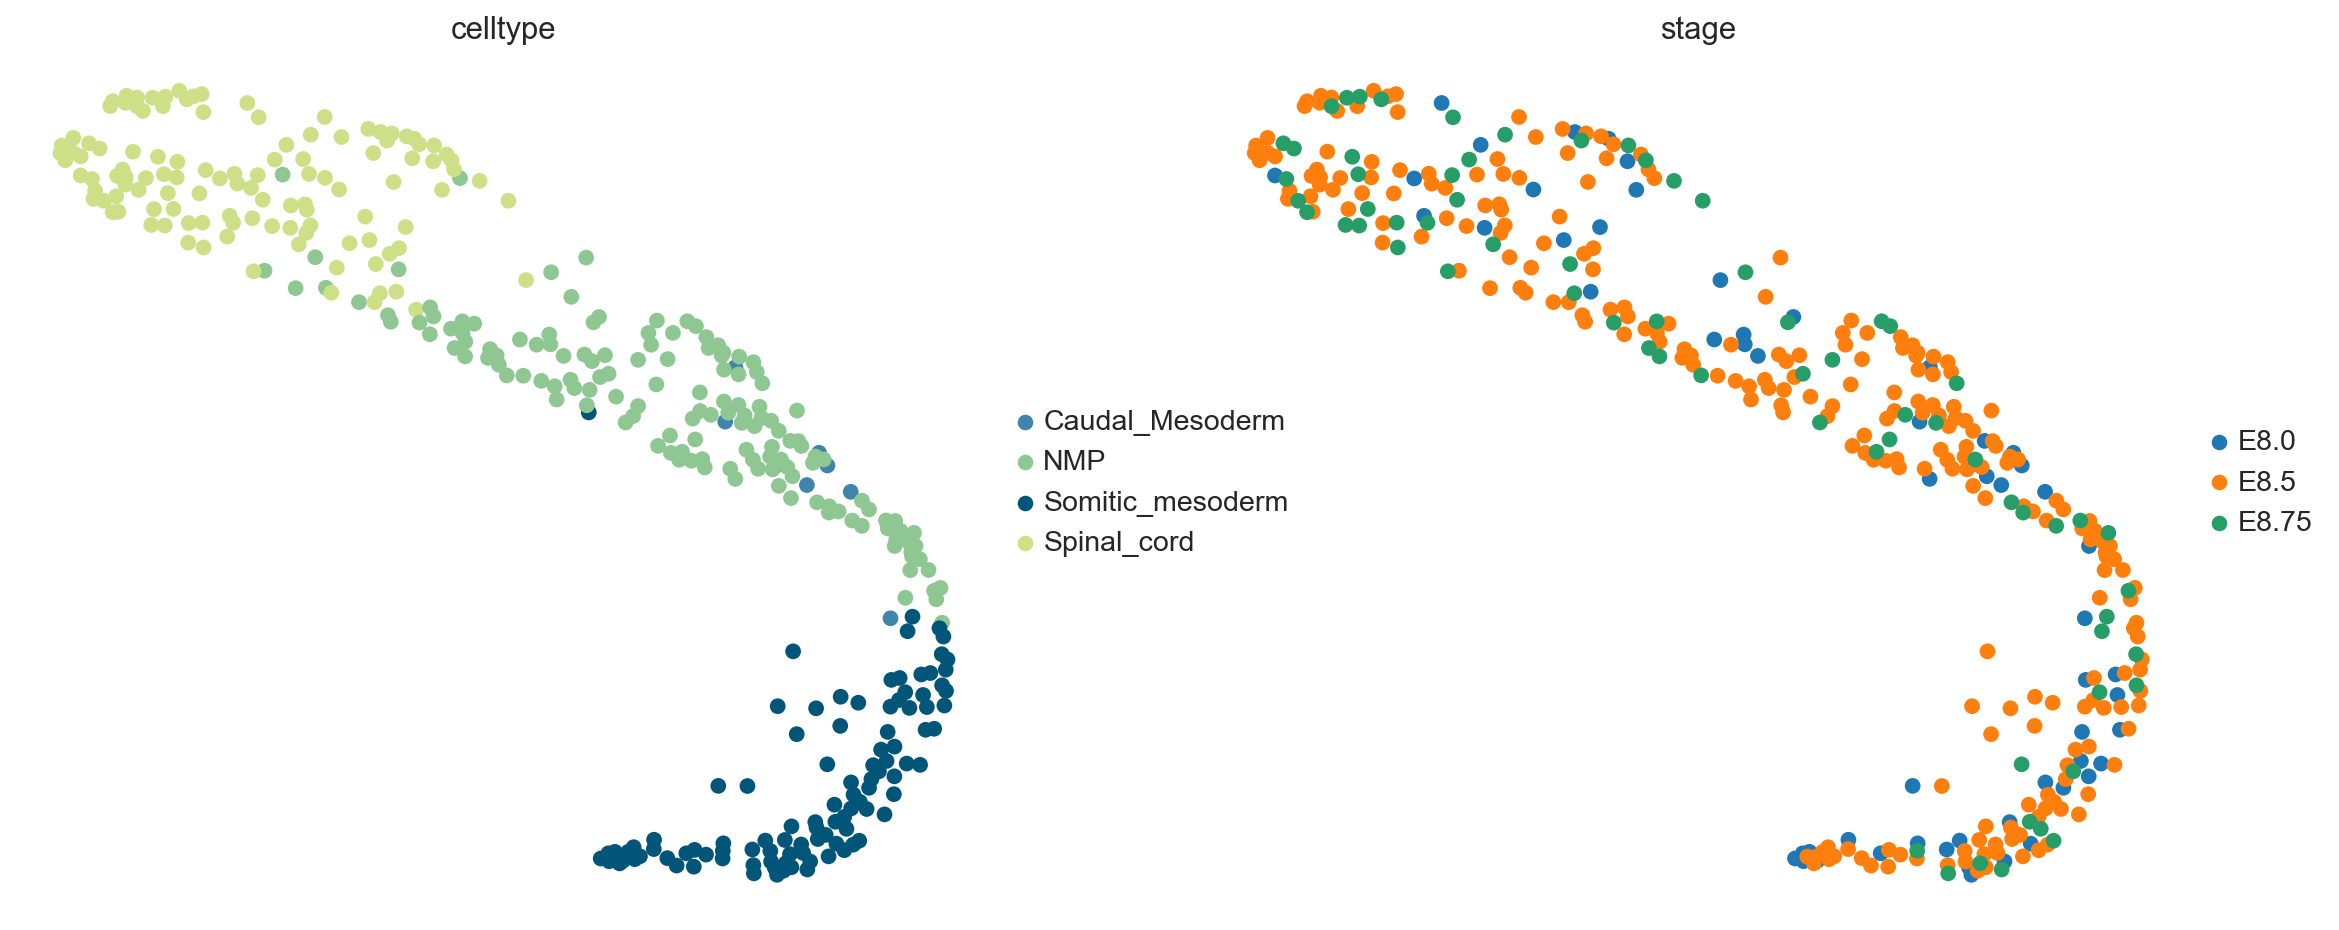

In [21]:
sc.pl.draw_graph(adata, color=["celltype","stage"], size=200)

## Prepare data for celloracle

In [22]:
adata.X = adata.layers["raw"].copy()

Load TF2gene links

In [26]:
tf2gene_df = pd.read_csv(io['tf2gene'],header=0, sep="\t", usecols=[1,3])
tf2gene_df.shape

(171974, 2)

Filter TF2gene links

In [27]:
tf2gene_df = tf2gene_df >> mask(X.tf.isin(["T","SOX2"]))

Convert to a dictionary

In [28]:
tmp = adata.var["gene"].str.upper().isin(tf2gene_df["tf"].values).values
adata.var["gene"][tmp] = adata.var["gene"][tmp].str.upper()

In [29]:
adata.var["gene"].str.upper().isin(tf2gene_df["tf"].values).sum()

2

In [30]:
adata.var_names = adata.var["gene"].values
adata.var_names

Index(['Xkr4', 'Gm1992', 'Rp1', 'Rgs20', 'Oprk1', 'Npbwr1', 'Alkal1', 'St18',
       'Pcmtd1', 'Gm30414',
       ...
       '4933400A11Rik', 'Kdm5d', 'Eif2s3y', 'Uty', 'Usp9y', 'Gm28930',
       'Gm21860', 'mt-Nd1', 'mt-Atp6', 'mt-Nd3'],
      dtype='object', length=5000)

Filter TFs

In [31]:
tf2gene_df = tf2gene_df[tf2gene_df["tf"].isin(adata.var_names)]
tf2gene_df.shape

(156, 2)

Filter genes

In [32]:
tf2gene_df = tf2gene_df[tf2gene_df["gene"].isin(adata.var_names)]
tf2gene_df.shape

(45, 2)

Convert to a dictionary

In [33]:
tf2gene_dic = tf2gene_df.groupby('gene')['tf'].apply(lambda x: x.tolist()).to_dict()

In [34]:
# np.isin(np.array(list(tf2gene_dic.keys())),adata.var_names).sum()
len(tf2gene_dic.keys())

43

# 2. Initiate Oracle object

In [35]:
oracle = co.Oracle()

## Load gene expression data into oracle object.

In [36]:
adata.var["symbol"] = adata.var.index.values
#adata.var["isin_top1000_var_mean_genes"] = True

create dummy column

In [37]:
adata.obs["foo"] = "foo"
adata.obs["foo"] = adata.obs["foo"].astype('category')

In [38]:
adata.uns["foo_colors"] = np.array(["#9e6762"])

Check adata object

In [39]:
adata.obsm

AxisArrays with keys: X_pca, X_draw_graph_fa

In [40]:
adata.X#.todense()

array([[1.7000e+01, 0.0000e+00, 0.0000e+00, ..., 4.8470e+03, 7.1340e+03,
        1.4190e+03],
       [4.7000e+01, 2.0000e+00, 0.0000e+00, ..., 6.9550e+03, 1.2259e+04,
        2.4850e+03],
       [1.5000e+01, 0.0000e+00, 0.0000e+00, ..., 1.7020e+03, 2.9090e+03,
        5.3500e+02],
       ...,
       [1.0000e+01, 0.0000e+00, 2.0000e+00, ..., 7.2650e+03, 1.3046e+04,
        2.6110e+03],
       [5.0000e+00, 0.0000e+00, 0.0000e+00, ..., 2.5800e+03, 3.7600e+03,
        8.1100e+02],
       [4.0000e+01, 0.0000e+00, 0.0000e+00, ..., 5.9970e+03, 7.7430e+03,
        1.4580e+03]], dtype=float32)

In [41]:
oracle.import_anndata_as_raw_count(adata=adata, cluster_column_name="foo", embedding_name="X_draw_graph_fa")

## 2.2. Load TFinfo into oracle object

In [42]:
oracle.import_TF_data(TFdict=tf2gene_dic)

Total number of TF was 2. Although we can go to the GRN calculation with this data, but the TF number is small.


In [43]:
#oracle.adata.var.loc[:,["isin_TFdict_targets","isin_TFdict_regulators"]]
oracle.adata.var.loc[:,"isin_TFdict_targets"].sum()

43

In [44]:
oracle.adata.var.loc[:,"isin_TFdict_regulators"].sum()

2

## Knn imputation

PCA

In [45]:
# Perform PCA
# oracle.perform_PCA()

# Select important PCs
# plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
# n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]
# plt.axvline(n_comps, c="k")

KNN imputation. It creates the attributes:
- knn (scipy.sparse.csr_matrix): knn contiguity matrix
- knn_smoothing_w (scipy.sparse.lil_matrix): the weights used for the smoothing

In [46]:
# k = 25
# oracle.knn_imputation(n_pca_dims=15, k=k, balanced=True, b_sight=k*8, b_maxl=k*4, n_jobs=4)
# oracle.knn.shape

In [47]:
oracle.adata.layers

Layers with keys: raw, raw_count, normalized_count

In [48]:
# oracle.adata.layers["normalized_count"]

## GRN calculation
The next step is constructing a cluster-specific GRN for all clusters.

The "get_links" function returns GRNs as a Links object which stores inferred GRNs and the corresponding metadata. You can do network analysis with the Links object.

In [49]:
import importlib
importlib.reload(co)
# co.__file__

1 package does not meet CellOracle requirement.
 Your h5py version is 2.10.0. Please install h5py>=3.1.0


<module 'celloracle' from '/Users/argelagr/git/CellOracle/celloracle/__init__.py'>

In [50]:
links = oracle.get_links(cluster_name_for_GRN_unit="foo", alpha=10, verbose_level=10, test_mode=False)
links

  0%|          | 0/1 [00:00<?, ?it/s]

inferring GRN for foo...


  0%|          | 0/43 [00:00<?, ?it/s]

In [51]:
links.links_dict["foo"].shape

(43, 6)

In [52]:
links.links_dict["foo"]

,source,target,coef_mean,coef_abs,p,-logp
0,SOX2,A730049H05Rik,0.554601,0.554601,7.467385e-23,22.126831
1,SOX2,Adamts9,0.316216,0.316216,1.182657e-19,18.927141
2,SOX2,Arhgap26,0.457832,0.457832,3.622806e-22,21.440955
3,SOX2,Bach2,0.440344,0.440344,7.678631e-21,20.114716
4,SOX2,Btrc,0.299473,0.299473,6.685618e-20,19.174858
5,T,Dclk1,0.037811,0.037811,8.238127e-03,2.084172
6,T,Epha4,0.539334,0.539334,3.646074e-26,25.438174
7,T,Fstl4,0.517846,0.517846,1.044176e-20,19.981226
8,SOX2,Fto,0.364789,0.364789,2.928102e-21,20.533414
9,SOX2,Gm26577,0.051292,0.051292,6.462026e-13,12.189631


### Exploration

The TF-gene connections from celloracle are missing important connections. For example:
GATA1 -> (Zfpm1, Gypc, Hdgf, Epor)

In [53]:
links.filter_links(p=0.001, weight="coef_abs")
links.links_dict["foo"].shape

(43, 6)

In [54]:
# links.links_dict["blood"] >> mask(X.source=="Gata1") >> arrange(X.p) >> head(n=15)
# links.get_network_entropy()
# links.entropy.head()
# links.plot_degree_distributions()
# links.get_score()
# links.plot_cartography_scatter_per_cluster()
# oracle.embedding

## Save

In [55]:
io['links_outfile'] = io['outdir'] / 'test.celloracle.links'
links.to_hdf5(str(io['links_outfile']))

In [56]:
io['oracle_outfile'] = io['outdir'] / "test.celloracle.oracle"
oracle.to_hdf5(str(io['oracle_outfile']))

# Explore

In [105]:
links.links_dict["foo"] >> mask(X.source=="T") >> arrange("coef_mean")

,source,target,coef_mean,coef_abs,p,-logp
31,T,Klhl29,-0.146538,0.146538,1.500727e-10,9.823698
34,T,Mesp2,-0.036525,0.036525,5.437994e-08,7.264561
5,T,Dclk1,0.037811,0.037811,8.238127e-03,2.084172
33,T,Mesp1,0.039839,0.039839,3.350979e-08,7.474828
36,T,Myof,0.127482,0.127482,6.615355e-14,13.179447
40,T,Spred2,0.248367,0.248367,3.670994e-17,16.435216
18,T,Hoxb3os,0.253656,0.253656,3.474662e-17,16.459087
11,T,Hoxa10,0.282372,0.282372,2.639188e-17,16.578530
37,T,Ptprk,0.283921,0.283921,5.771033e-20,19.238746
17,T,Hoxb3,0.371734,0.371734,7.737908e-21,20.111376


In [104]:
links.links_dict["foo"] >> mask(X.source=="SOX2") >> arrange("coef_mean")

,source,target,coef_mean,coef_abs,p,-logp
27,SOX2,Ifitm5,-0.262780,0.262780,8.834675e-18,17.053809
25,SOX2,Ifitm1,-0.167894,0.167894,8.312872e-17,16.080249
41,SOX2,Spry4,-0.144866,0.144866,1.355481e-10,9.867907
9,SOX2,Gm26577,0.051292,0.051292,6.462026e-13,12.189631
28,SOX2,Ikzf3,0.070857,0.070857,3.169304e-13,12.499036
26,SOX2,Ifitm2,0.117527,0.117527,9.519287e-15,14.021396
30,SOX2,Kdr,0.257933,0.257933,2.622264e-17,16.581324
4,SOX2,Btrc,0.299473,0.299473,6.685618e-20,19.174858
1,SOX2,Adamts9,0.316216,0.316216,1.182657e-19,18.927141
8,SOX2,Fto,0.364789,0.364789,2.928102e-21,20.533414


In [58]:
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)

In [90]:
oracle.fit_GRN_for_simulation(alpha=10, use_cluster_specific_TFdict=True)

fitting GRN again...
calculating GRN in foo


  0%|          | 0/5000 [00:00<?, ?it/s]

genes_in_gem: 5000
models made for 42 genes


In [91]:
gene = "SOX2"

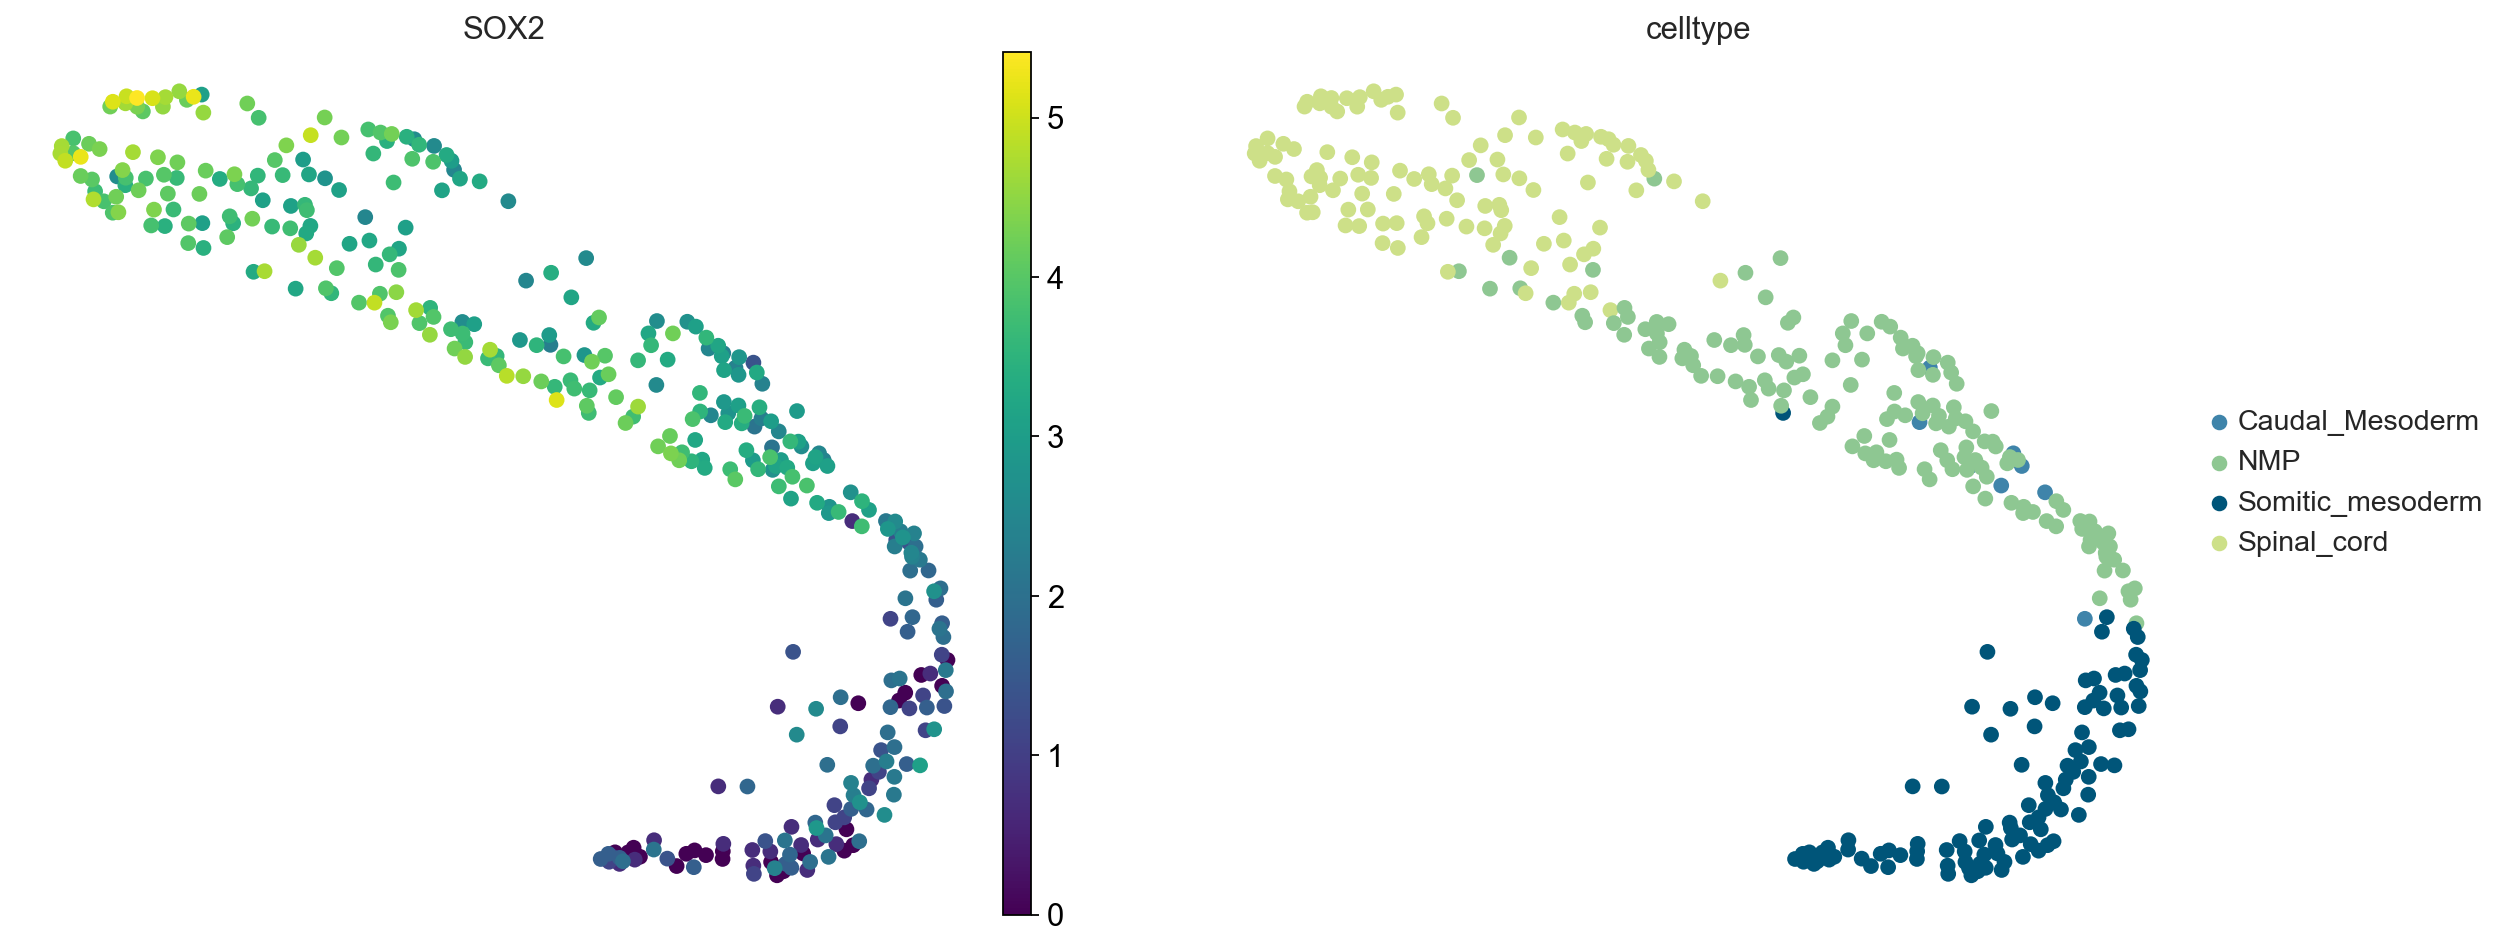

In [92]:
sc.pl.draw_graph(oracle.adata, color=[gene,'celltype'], size=200, layer="normalized_count", cmap="viridis")

In [93]:
oracle.simulate_shift(perturb_condition={gene: 0.0}, n_propagation=3)

In [94]:
import importlib
importlib.reload(co)
# co.__file__

1 package does not meet CellOracle requirement.
 Your h5py version is 2.10.0. Please install h5py>=3.1.0


<module 'celloracle' from '/Users/argelagr/git/CellOracle/celloracle/__init__.py'>

In [95]:
oracle.estimate_transition_prob(n_neighbors=15, knn_random=True, sampled_fraction=1)

In [96]:
oracle.calculate_embedding_shift(sigma_corr = 0.05)

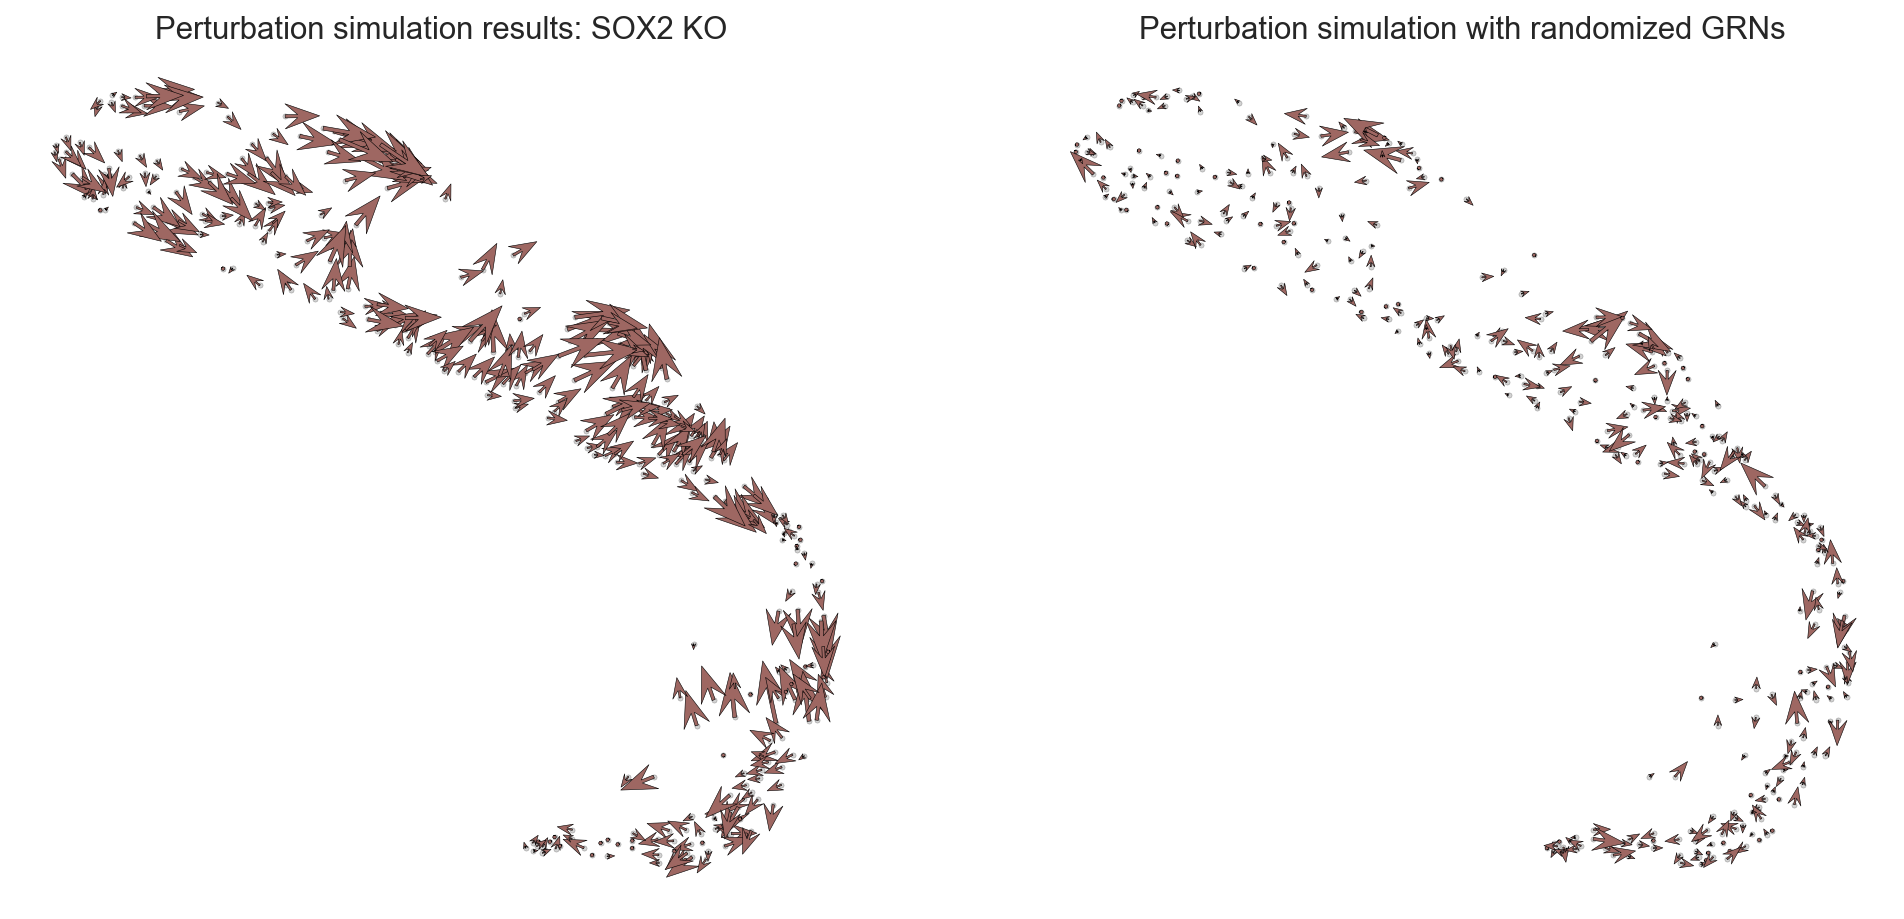

In [97]:
fig, ax = plt.subplots(1, 2,  figsize=[15, 7])
scale = 5
oracle.plot_quiver(scale=scale, ax=ax[0])
ax[0].set_title(f"Perturbation simulation results: {gene} KO")
oracle.plot_quiver_random(scale=scale, ax=ax[1])
ax[1].set_title(f"Perturbation simulation with randomized GRNs")
plt.show()

In [98]:
oracle.calculate_p_mass(smooth=0.8, n_grid=40, n_neighbors=15)

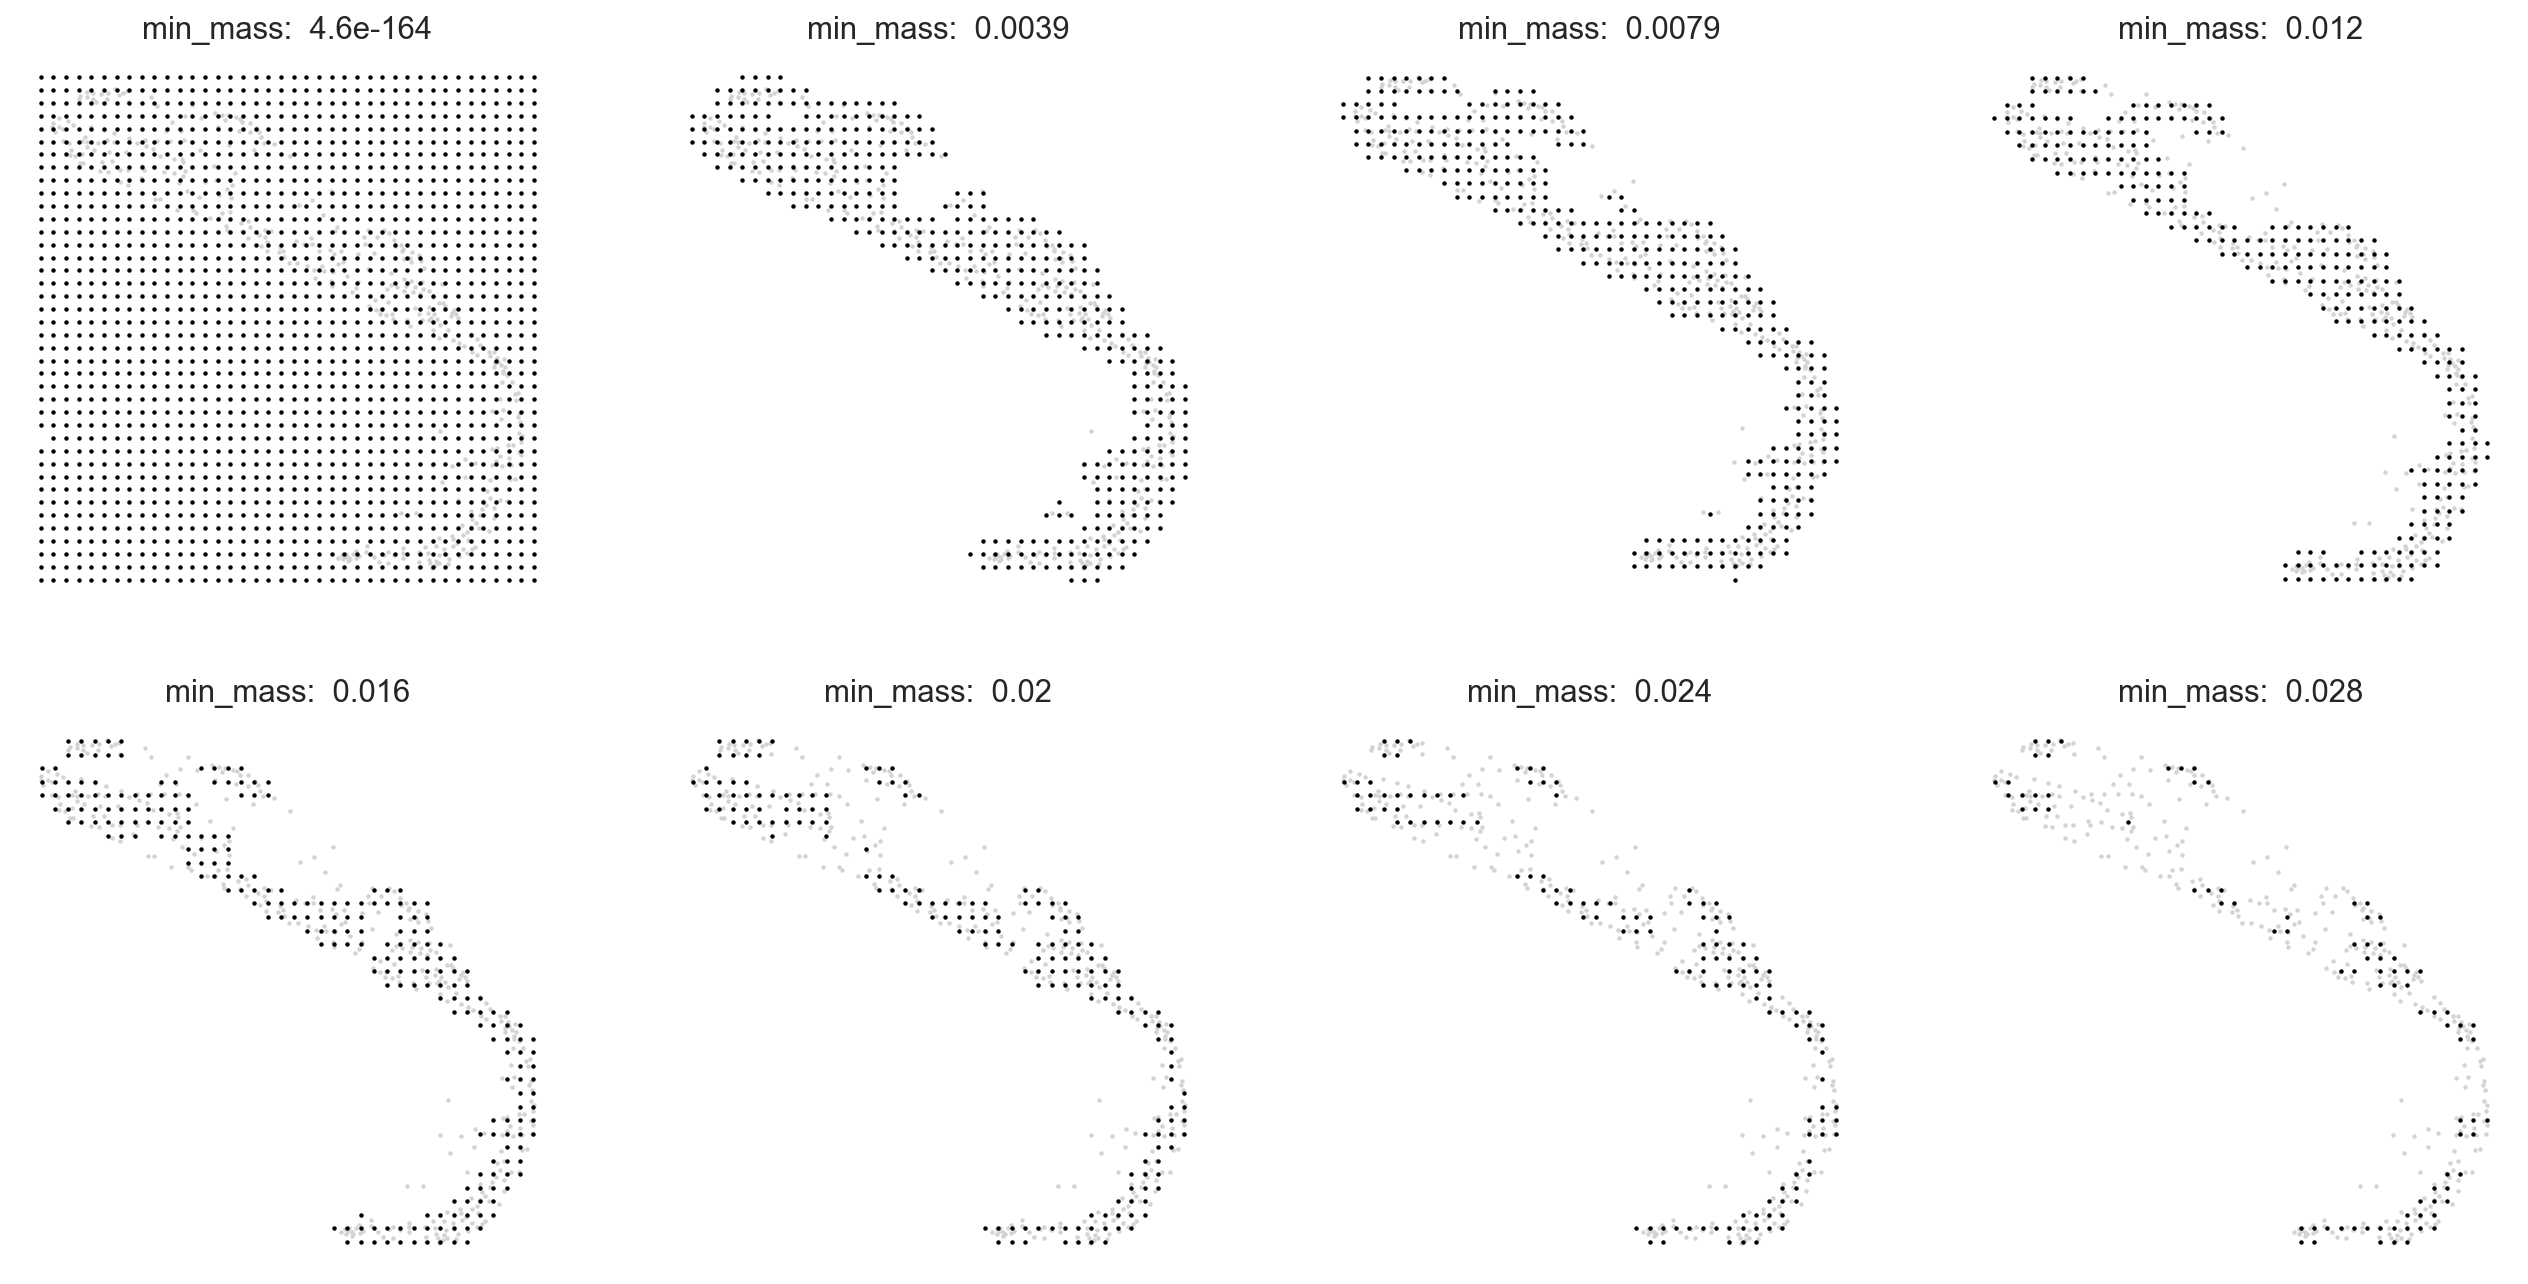

In [99]:
oracle.suggest_mass_thresholds(n_suggestion=8)

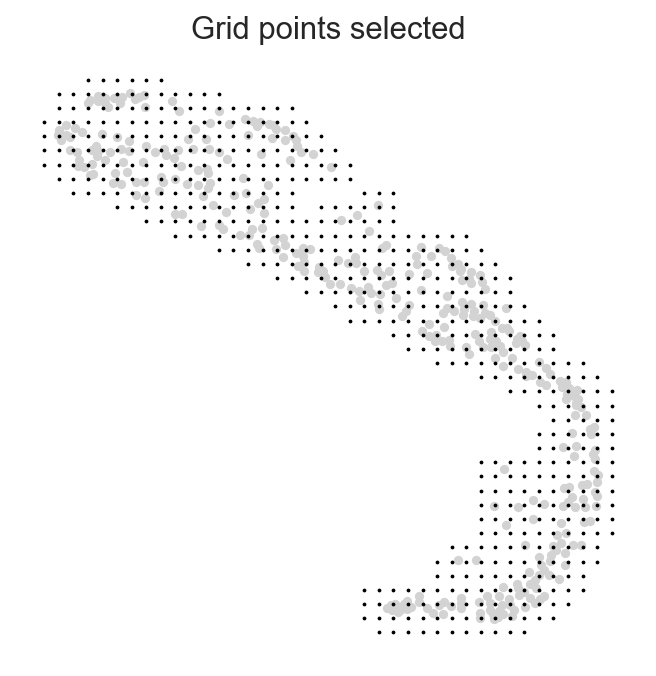

In [100]:
min_mass = 0.001
oracle.calculate_mass_filter(min_mass=min_mass, plot=True)

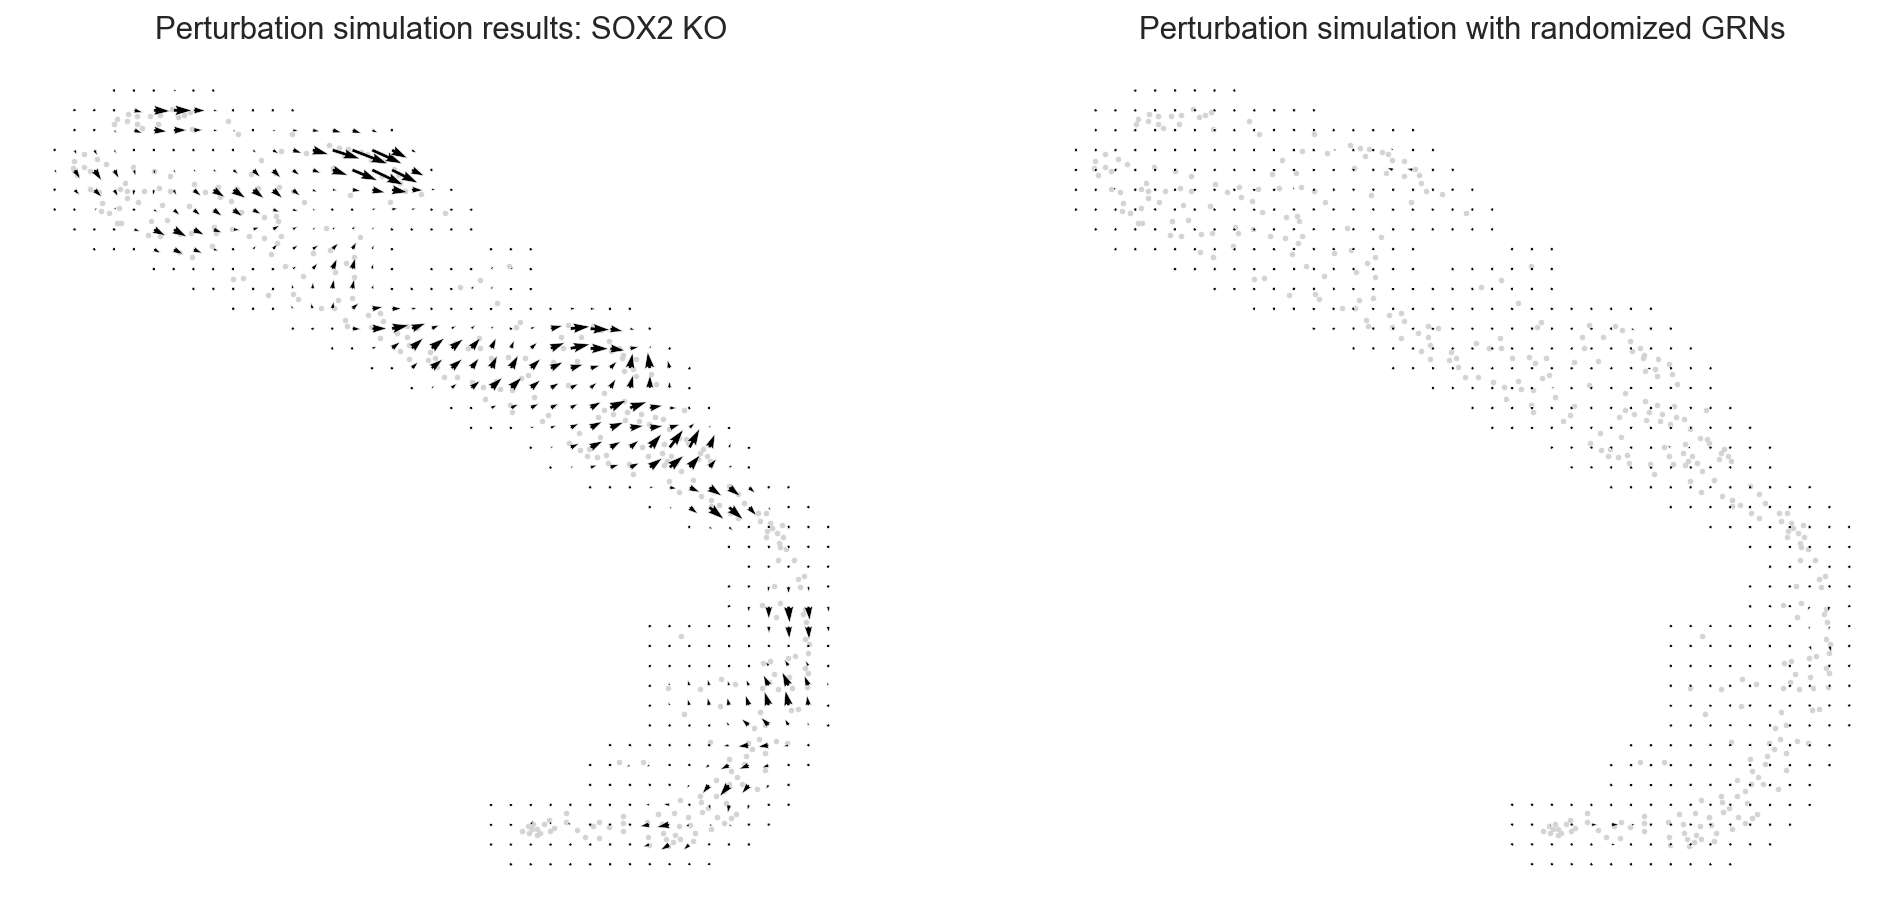

In [101]:
fig, ax = plt.subplots(1, 2,  figsize=[15, 7])
scale_simulation = 0.25
oracle.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax[0])
ax[0].set_title(f"Perturbation simulation results: {gene} KO")
oracle.plot_simulation_flow_random_on_grid(scale=scale_simulation, ax=ax[1])
ax[1].set_title(f"Perturbation simulation with randomized GRNs")
plt.show()

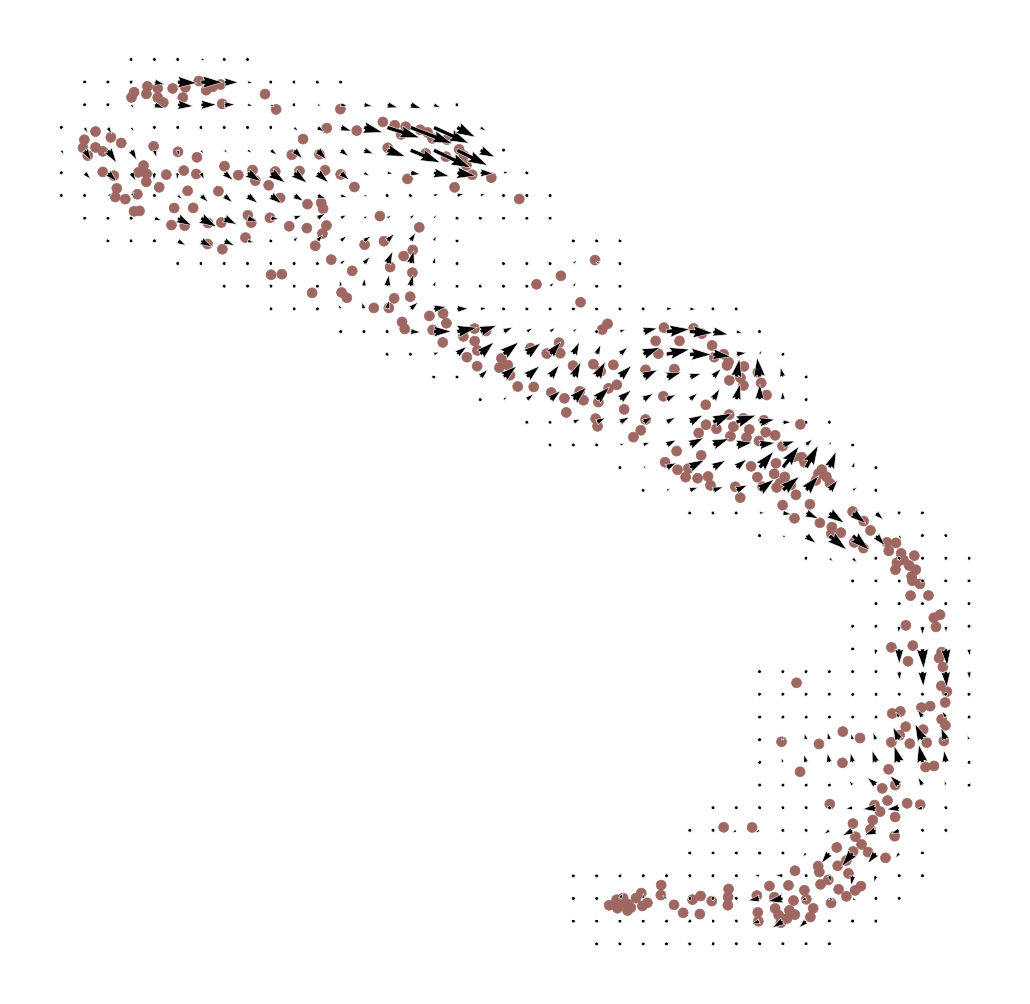

In [102]:
fig, ax = plt.subplots(figsize=[8, 8])
oracle.plot_cluster_whole(ax=ax, s=20)
oracle.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax, show_background=False)